In [ ]:
import pandas as pd

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
import numpy as np

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

In [ ]:
from sklearn.metrics import classification_report

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
from sklearn.tree import DecisionTreeClassifier

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
from sklearn.cluster import KMeans

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
import seaborn as sns

In [ ]:
df= pd.read_csv(r'C:\Users\allwe\Downloads\data set\credit analysis\german_credit_data.csv')

In [ ]:
df.describe()

,Unnamed: 0,Age,Job,Credit amount,Duration
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,499.500000,35.546000,1.904000,3271.258000,20.903000
std,288.819436,11.375469,0.653614,2822.736876,12.058814
min,0.000000,19.000000,0.000000,250.000000,4.000000
25%,249.750000,27.000000,2.000000,1365.500000,12.000000
50%,499.500000,33.000000,2.000000,2319.500000,18.000000
75%,749.250000,42.000000,2.000000,3972.250000,24.000000
max,999.000000,75.000000,3.000000,18424.000000,72.000000


In [ ]:
df.isnull().sum()

Unnamed: 0            0
Age                   0
Sex                   0
Job                   0
Housing               0
Saving accounts     183
Checking account    394
Credit amount         0
Duration              0
Purpose               0
dtype: int64

In [ ]:
df.head(20)

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose
0,0,67,male,2,own,NaN,little,1169,6,radio/TV
1,1,22,female,2,own,little,moderate,5951,48,radio/TV
2,2,49,male,1,own,little,NaN,2096,12,education
3,3,45,male,2,free,little,little,7882,42,furniture/equipment
4,4,53,male,2,free,little,little,4870,24,car
5,5,35,male,1,free,NaN,NaN,9055,36,education
6,6,53,male,2,own,quite rich,NaN,2835,24,furniture/equipment
7,7,35,male,3,rent,little,moderate,6948,36,car
8,8,61,male,1,own,rich,NaN,3059,12,radio/TV
9,9,28,male,3,own,little,moderate,5234,30,car


In [ ]:
df.duplicated().sum()

0

In [ ]:
df.shape

(1000, 10)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Unnamed: 0        1000 non-null   int64 
 1   Age               1000 non-null   int64 
 2   Sex               1000 non-null   object
 3   Job               1000 non-null   int64 
 4   Housing           1000 non-null   object
 5   Saving accounts   817 non-null    object
 6   Checking account  606 non-null    object
 7   Credit amount     1000 non-null   int64 
 8   Duration          1000 non-null   int64 
 9   Purpose           1000 non-null   object
dtypes: int64(5), object(5)
memory usage: 78.3+ KB


<ipython-input-20-4e80649a328c>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax=sns.countplot(data=df,x='Saving accounts',palette='deep')


([0, 1, 2, 3],
 [Text(0, 0, 'little'),
  Text(1, 0, 'quite rich'),
  Text(2, 0, 'rich'),
  Text(3, 0, 'moderate')])

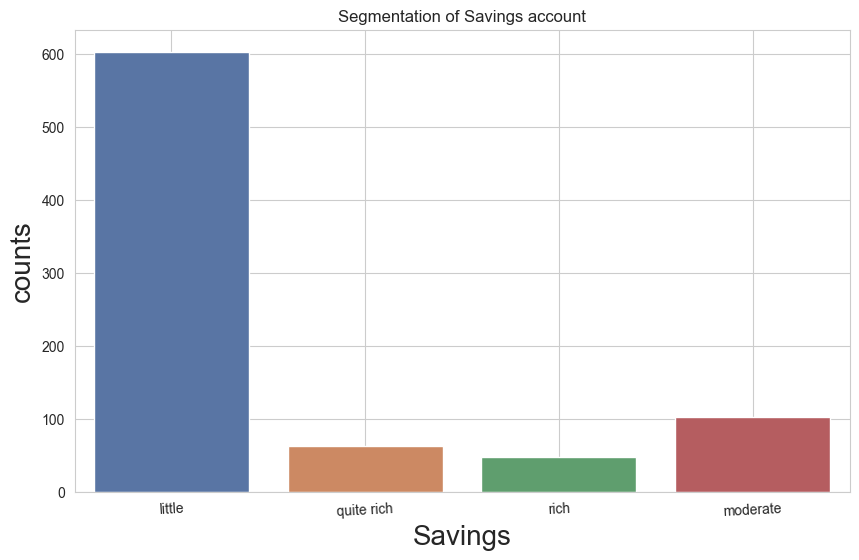

In [ ]:
sns.set_style('whitegrid')
plt.figure(figsize=(10,6))
ax=sns.countplot(data=df,x='Saving accounts',palette='deep')
plt.title('Segmentation of Savings account')
plt.xlabel('Savings', fontsize=20)
plt.ylabel('counts', fontsize=20)
plt.grid(True,zorder=0)
ax.set_axisbelow(True)
plt.xticks(rotation=3)

<ipython-input-21-10906ba030e9>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax=sns.countplot(data=df,x='Job',palette='coolwarm')


([0, 1, 2, 3],
 [Text(0, 0, '0'), Text(1, 0, '1'), Text(2, 0, '2'), Text(3, 0, '3')])

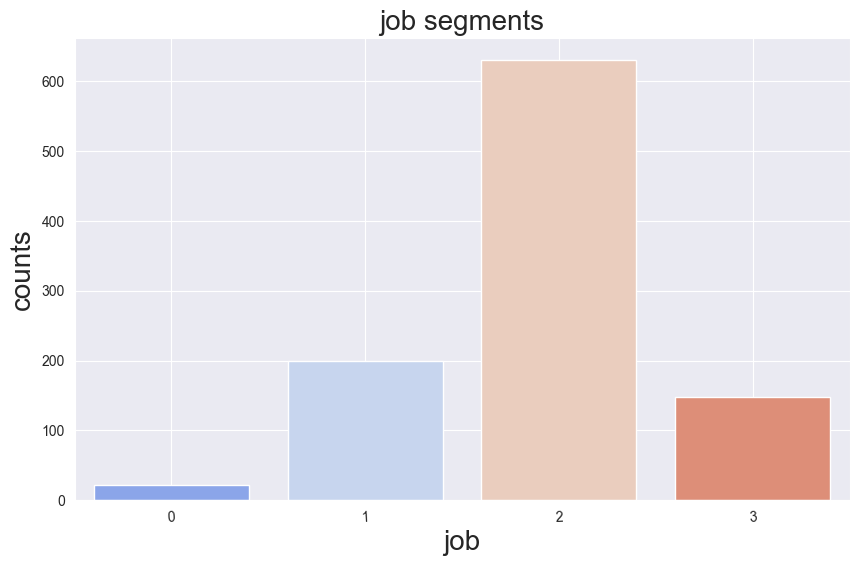

In [ ]:
sns.set_style('darkgrid')
plt.figure(figsize=(10,6))
ax=sns.countplot(data=df,x='Job',palette='coolwarm')
plt.title('job segments', fontsize=20)
plt.xlabel('job', fontsize=20)
plt.ylabel('counts', fontsize=20)
plt.grid(True,zorder=0)
ax.set_axisbelow(True)
plt.xticks(rotation=3)

<ipython-input-22-dde8b121e81d>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax=sns.countplot(data=df,x='Purpose',palette='Reds')


([0, 1, 2, 3, 4, 5, 6, 7],
 [Text(0, 0, 'radio/TV'),
  Text(1, 0, 'education'),
  Text(2, 0, 'furniture/equipment'),
  Text(3, 0, 'car'),
  Text(4, 0, 'business'),
  Text(5, 0, 'domestic appliances'),
  Text(6, 0, 'repairs'),
  Text(7, 0, 'vacation/others')])

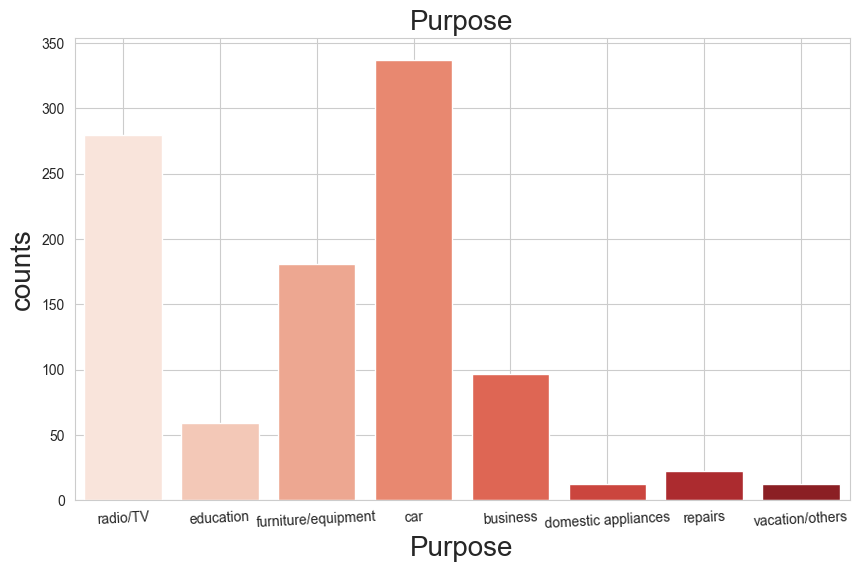

In [ ]:
sns.set_style('whitegrid')
plt.figure(figsize=(10,6))
ax=sns.countplot(data=df,x='Purpose',palette='Reds')
plt.title('Purpose', fontsize=20)
plt.xlabel('Purpose', fontsize=20)
plt.ylabel('counts', fontsize=20)
plt.grid(True,zorder=0)
ax.set_axisbelow(True)
plt.xticks(rotation=3)

<ipython-input-23-ac75386135a7>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax=sns.countplot(data=df,x='Checking account',palette='bright')


([0, 1, 2], [Text(0, 0, 'little'), Text(1, 0, 'moderate'), Text(2, 0, 'rich')])

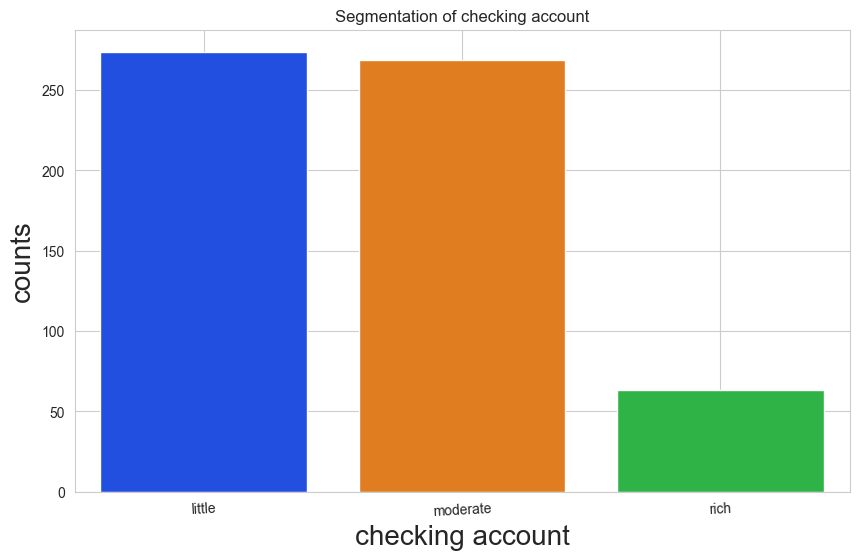

In [ ]:
sns.set_style('whitegrid')
plt.figure(figsize=(10,6))
ax=sns.countplot(data=df,x='Checking account',palette='bright')
plt.title('Segmentation of checking account')
plt.xlabel('checking account', fontsize=20)
plt.ylabel('counts', fontsize=20)
plt.grid(True,zorder=0)
ax.set_axisbelow(True)
plt.xticks(rotation=3)

<ipython-input-24-3fee7f648a55>:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax=sns.countplot(data=df,x='Housing', palette='pastel')


([0, 1, 2], [Text(0, 0, 'own'), Text(1, 0, 'free'), Text(2, 0, 'rent')])

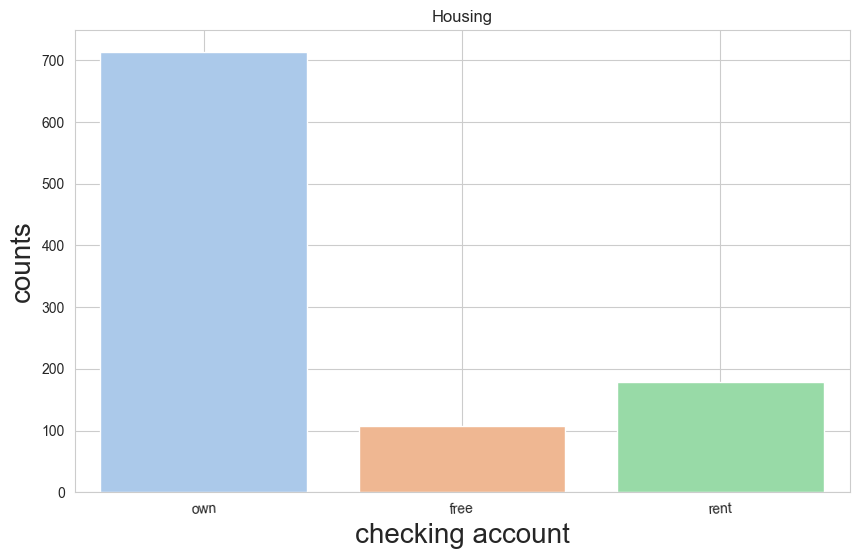

In [ ]:
sns.set_style('whitegrid')
plt.figure(figsize=(10,6))
ax=sns.countplot(data=df,x='Housing', palette='pastel')
plt.title('Housing')
plt.xlabel('checking account', fontsize=20)
plt.ylabel('counts', fontsize=20)
plt.grid(True,zorder=0)
ax.set_axisbelow(True)
plt.xticks(rotation=3)

<ipython-input-25-3f3fb2c9d428>:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Checking account', y='Credit amount', palette='Blues', ax=axes[0])
<ipython-input-25-3f3fb2c9d428>:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Saving accounts',y='Credit amount', palette='deep', ax=axes[1])


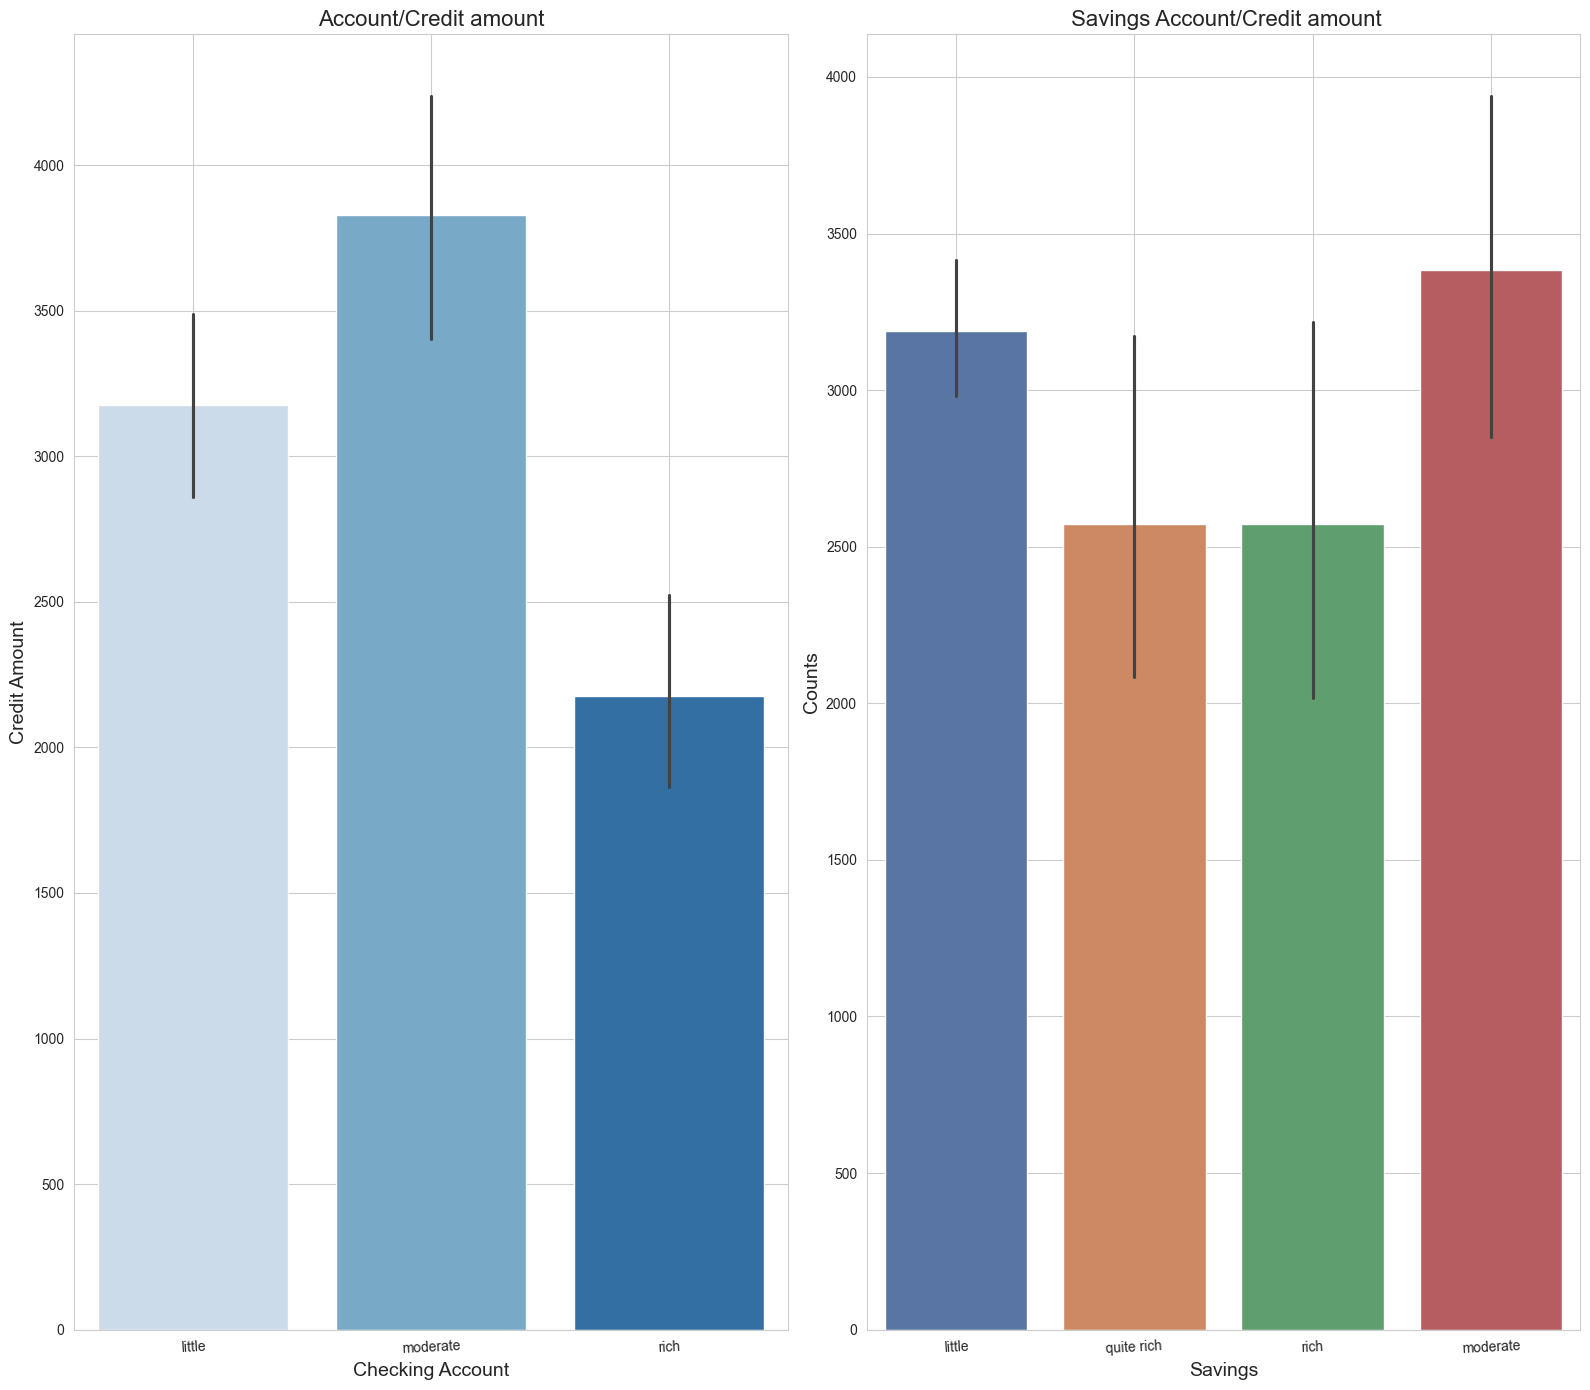

In [ ]:
sns.set_style('whitegrid')

fig, axes = plt.subplots(1, 2, figsize=(16, 14))


sns.barplot(data=df, x='Checking account', y='Credit amount', palette='Blues', ax=axes[0])
axes[0].set_title('Account/Credit amount', fontsize=16)
axes[0].set_xlabel('Checking Account', fontsize=14)
axes[0].set_ylabel('Credit Amount', fontsize=14)
axes[0].grid(True, zorder=0)
axes[0].set_axisbelow(True)
axes[0].tick_params(axis='x', rotation=3)

sns.barplot(data=df, x='Saving accounts',y='Credit amount', palette='deep', ax=axes[1])
axes[1].set_title(' Savings Account/Credit amount', fontsize=16)
axes[1].set_xlabel('Savings', fontsize=14)
axes[1].set_ylabel('Counts', fontsize=14)
axes[1].grid(True, zorder=0)
axes[1].set_axisbelow(True)
axes[1].tick_params(axis='x', rotation=3) 

plt.tight_layout()

<ipython-input-26-e604a7ad42a2>:3: UserWarning: Ignoring `palette` because no `hue` variable has been assigned.
  ax=sns.histplot(data=df,x='Age', bins=10, palette='Greens')


(array([10., 20., 30., 40., 50., 60., 70., 80.]),
 [Text(10.0, 0, '10'),
  Text(20.0, 0, '20'),
  Text(30.0, 0, '30'),
  Text(40.0, 0, '40'),
  Text(50.0, 0, '50'),
  Text(60.0, 0, '60'),
  Text(70.0, 0, '70'),
  Text(80.0, 0, '80')])

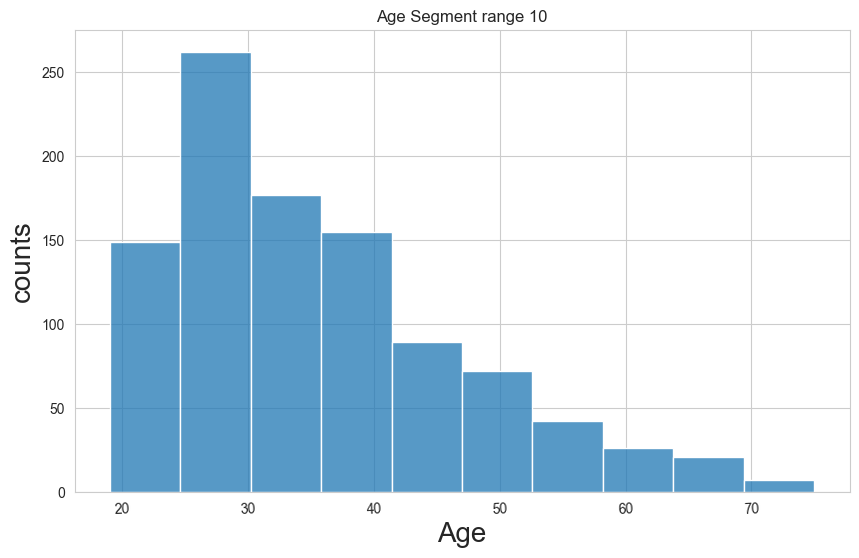

In [ ]:
sns.set_style('whitegrid')
plt.figure(figsize=(10,6))
ax=sns.histplot(data=df,x='Age', bins=10, palette='Greens')
plt.title('Age Segment range 10')
plt.xlabel('Age', fontsize=20)
plt.ylabel('counts', fontsize=20)
plt.grid(True,zorder=0)
ax.set_axisbelow(True)
plt.xticks(rotation=3)

In [ ]:
df=df.dropna()

In [ ]:
df.isna().sum()

Unnamed: 0          0
Age                 0
Sex                 0
Job                 0
Housing             0
Saving accounts     0
Checking account    0
Credit amount       0
Duration            0
Purpose             0
dtype: int64

In [ ]:
df=df.drop_duplicates()

In [ ]:
df.duplicated().sum()

0

In [ ]:
df.shape

(522, 10)

In [ ]:
df.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose
1,1,22,female,2,own,little,moderate,5951,48,radio/TV
3,3,45,male,2,free,little,little,7882,42,furniture/equipment
4,4,53,male,2,free,little,little,4870,24,car
7,7,35,male,3,rent,little,moderate,6948,36,car
9,9,28,male,3,own,little,moderate,5234,30,car


In [ ]:
df=df.drop(columns='Unnamed: 0')

In [ ]:
df=df.drop(columns='Purpose')

In [ ]:
Sex=pd.get_dummies(df['Sex'], drop_first=True).astype(int)

In [ ]:
Sex

,male
1,0
3,1
4,1
7,1
9,1
...,...
989,1
993,1
996,1
998,1


In [ ]:
Savings =pd.get_dummies(df['Saving accounts'], drop_first=True).astype(int)

In [ ]:
Checking=pd.get_dummies(df['Checking account'], drop_first=True).astype(int)

In [ ]:
Housing=pd.get_dummies(df['Housing'], drop_first=True).astype(int)

In [ ]:
df=pd.concat([df,Sex,Savings,Checking,Housing],axis=1)

In [ ]:
df.drop(columns=['Sex','Saving accounts','Checking account','Housing'],axis=1,inplace=True)

In [ ]:
df.dtypes

Age              int64
Job              int64
Credit amount    int64
Duration         int64
male             int32
moderate         int32
quite rich       int32
rich             int32
moderate         int32
rich             int32
own              int32
rent             int32
dtype: object

In [ ]:
X = df.select_dtypes(include=[np.number])  # Select only numeric columns

In [ ]:
X

,Age,Job,Credit amount,Duration,male,moderate,quite rich,rich,moderate,rich,own,rent
1,22,2,5951,48,0,0,0,0,1,0,1,0
3,45,2,7882,42,1,0,0,0,0,0,0,0
4,53,2,4870,24,1,0,0,0,0,0,0,0
7,35,3,6948,36,1,0,0,0,1,0,0,1
9,28,3,5234,30,1,0,0,0,1,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
989,48,1,1743,24,1,0,0,0,1,0,1,0
993,30,3,3959,36,1,0,0,0,0,0,1,0
996,40,3,3857,30,1,0,0,0,0,0,1,0
998,23,2,1845,45,1,0,0,0,0,0,0,0


In [ ]:
X.dtypes

Age              int64
Job              int64
Credit amount    int64
Duration         int64
male             int32
moderate         int32
quite rich       int32
rich             int32
moderate         int32
rich             int32
own              int32
rent             int32
dtype: object

In [ ]:
scaler = StandardScaler()

In [ ]:
X_scaled = scaler.fit_transform(X)

In [ ]:
inertia = []

In [ ]:
K_range = range(1, 11)  # Checking 1 to 10 clusters

In [ ]:
for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)  # ✅ Correct usage
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

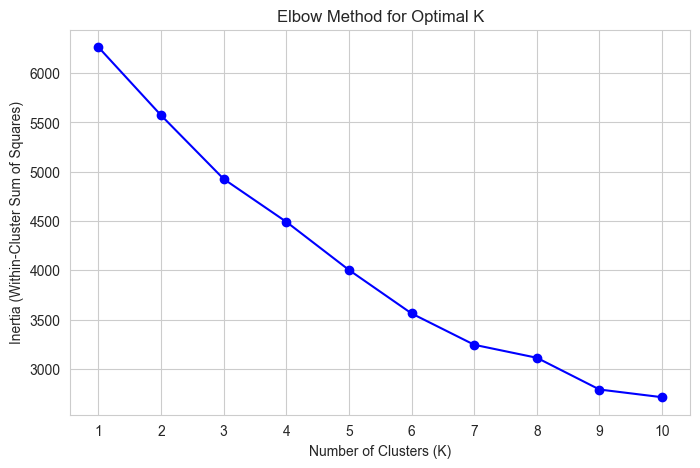

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, marker='o', linestyle='-', color='b')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia (Within-Cluster Sum of Squares)')
plt.title('Elbow Method for Optimal K')
plt.xticks(K_range)
plt.grid(True)
plt.show()

In [ ]:
optimal_k = 7  # Choose based on the elbow method

In [ ]:
kmeans = KMeans(n_clusters=optimal_k, random_state=42)

In [ ]:
df['Cluster'] = kmeans.fit_predict(X_scaled)

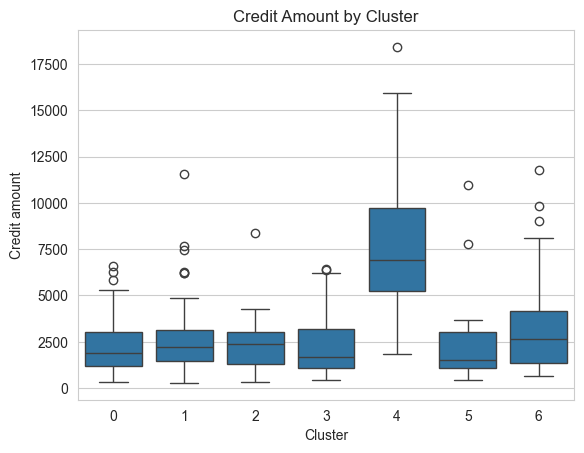

In [ ]:
sns.boxplot(x='Cluster', y='Credit amount', data=df)
plt.title('Credit Amount by Cluster')
plt.show()